In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import fft


# Partie 0 – Prise en main : filtrage d’un signal synthétique

1. Représentez 𝑥[𝑘] dans le temps et son spectre |𝑋[𝑛]|.
2. Définissez une sliding average (convolution) et testez 𝑆 = 11 puis 𝑆 = 31.
3. Comparez les signaux filtrés dans le temps et en fréquence (effet low‑pass de la sliding average).
4. Appliquez une fenêtre de Hann à 𝑥[𝑘] avant la DFT et comparez le spectre avec et sans fenêtre (spectral leak).
5. Répondez en 3‑4 lignes : convolution dans le temps versus multiplication en fréquence.



In [2]:
frequency = 8000
length = 2
N = frequency * length
k = np.arange(N)
signal = np.sin(2 * np.pi * 120 * k / frequency) + 0.6 * np.sin(2 * np.pi * 600 * k / frequency) + 0.3 * np.sin(2 * np.pi * 1400 * k / frequency)

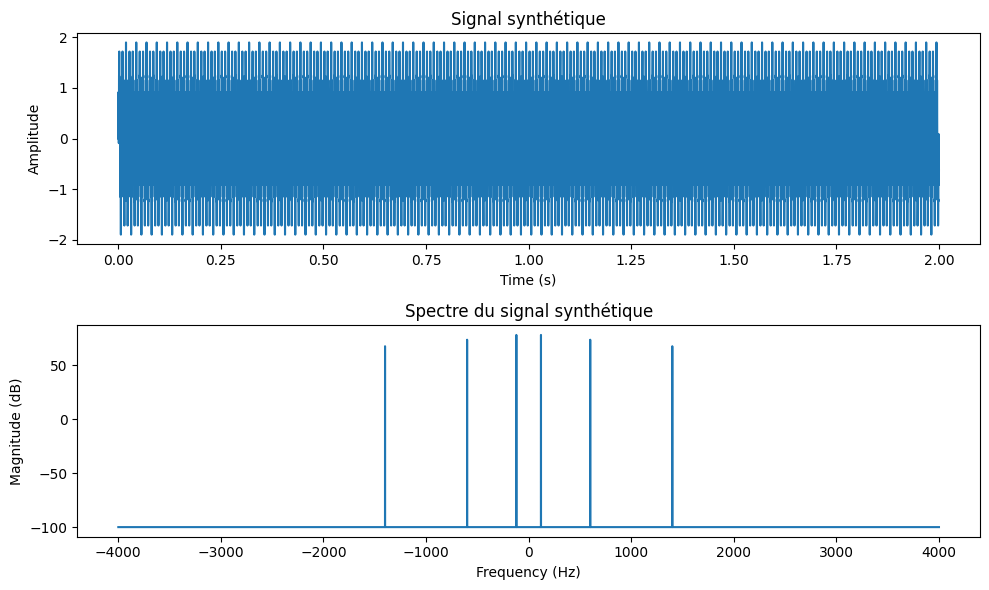

In [3]:
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(k / frequency, signal)
plt.title('Signal synthétique')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.subplot(2, 1, 2)


x = fft.fftshift(fft.fft(signal))
Pxx = 10 * np.log10(np.maximum(np.real(x * np.conj(x)), 1e-10))
f = fft.fftshift(fft.fftfreq(N, d=1/frequency))
plt.plot(f, Pxx)
plt.title('Spectre du signal synthétique')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.tight_layout()
plt.show()

In [4]:


def sliding_average(signal, window_size):
    kernel = np.ones(window_size) / window_size
    return np.convolve(signal, kernel, mode='valid')

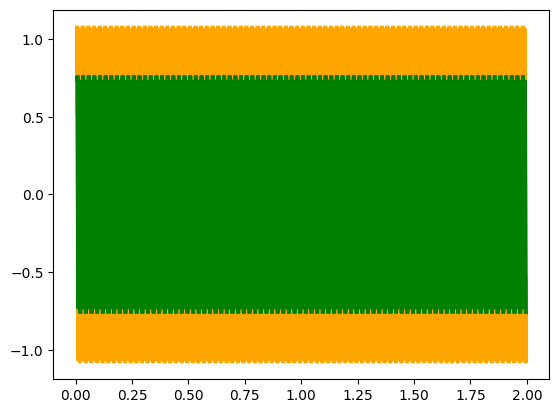

In [5]:

for S, color in [(11, 'orange'), (31, 'green')]:
    filtered = sliding_average(signal, S)
    plt.plot(k[S-1:] / frequency, filtered, label=f'S={S}', color=color)

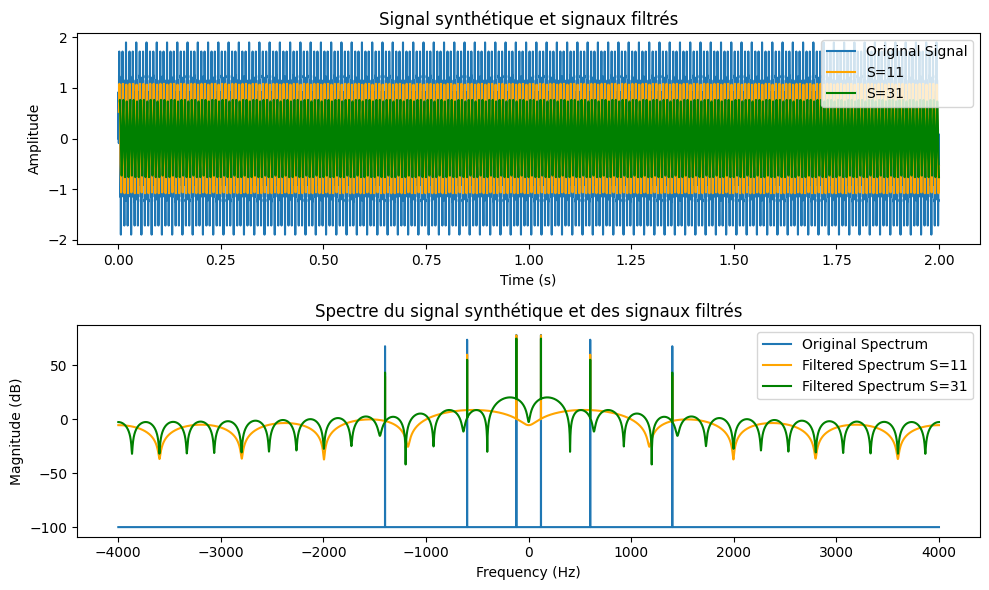

In [6]:
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(k / frequency, signal, label='Original Signal')
for S, color in [(11, 'orange'), (31, 'green')]:
    filtered = sliding_average(signal, S)
    plt.plot(k[S-1:] / frequency, filtered, label=f'S={S}', color=color)
plt.title('Signal synthétique et signaux filtrés')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.subplot(2, 1, 2)
x_filtered_11 = fft.fftshift(fft.fft(sliding_average(signal, 11), n=N))
Pxx_filtered_11 = 10 * np.log10(np.maximum(np.real(x_filtered_11 * np.conj(x_filtered_11)), 1e-10))
x_filtered_31 = fft.fftshift(fft.fft(sliding_average(signal, 31), n=N))
Pxx_filtered_31 = 10 * np.log10(np.maximum(np.real(x_filtered_31 * np.conj(x_filtered_31)), 1e-10))
plt.plot(f, Pxx, label='Original Spectrum')
plt.plot(f, Pxx_filtered_11, label='Filtered Spectrum S=11', color='orange')
plt.plot(f, Pxx_filtered_31, label='Filtered Spectrum S=31', color='green')
plt.title('Spectre du signal synthétique et des signaux filtrés')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
signal_windowed = signal * np.hanning(N)

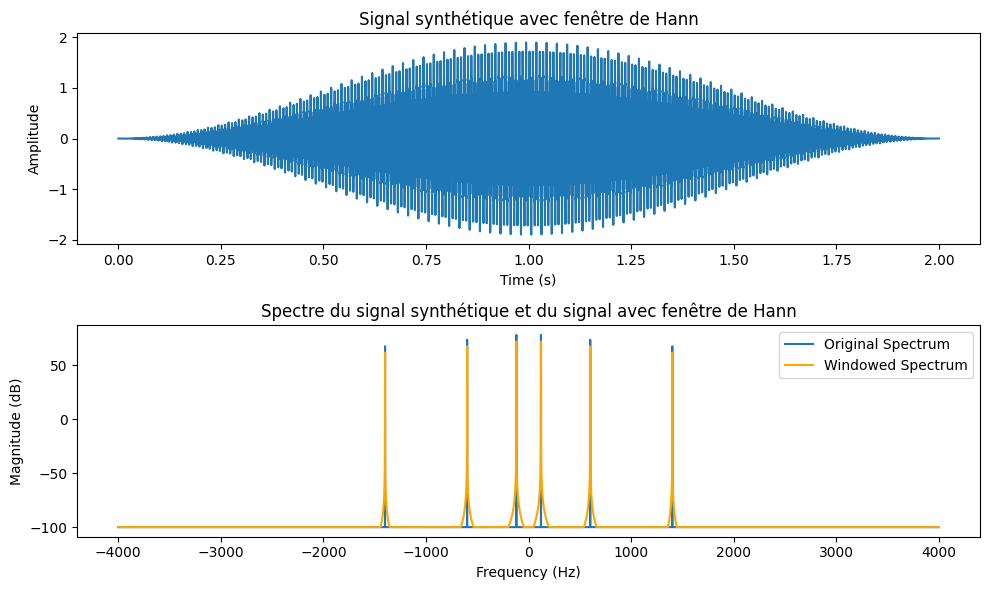

In [8]:
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(k / frequency, signal_windowed)
plt.title('Signal synthétique avec fenêtre de Hann')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.subplot(2, 1, 2)

x_windowed = fft.fftshift(fft.fft(signal_windowed))
Pxx_windowed = 10 * np.log10(np.maximum(np.real(x_windowed * np.conj(x_windowed)), 1e-10))
plt.plot(f, Pxx, label='Original Spectrum')
plt.plot(f, Pxx_windowed, label='Windowed Spectrum', color='orange')
plt.title('Spectre du signal synthétique et du signal avec fenêtre de Hann')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.tight_layout()
plt.show()

# Partie 1 – Doom
Il paraît que Mick Gordon a introduit un message dans la bande son du jeu Doom de 2016.
+ Ecrivez un script qui calcule le spectrogramme d’un signal. On aimerait pouvoir régler le nombre de pas
de temps contenu dans chaque tronçon et le nombre de pas de temps qui se superposent d’un tronçon
au suivant. En sortie, on aimerait la matrice du spectrogramme (i.e., une matrice de nombres complexes)
et sa représentation graphique.
+ Enregistrez la bande son du morceau Cyberdemon de la bande son du jeu Doom (2016).
+ Calculez et représentez le spectrogramme de ce morceau de musique. Afinez les réglages afin de faire
ressortir le message de Mick Grodon.

In [9]:
wav_file = 'output_with_hidden_message.wav'

sample_rate, data = wavfile.read(wav_file)

# Don't merge — split channels
left  = data[:, 0].astype(np.float32)
right = data[:, 1].astype(np.float32)



In [10]:
def spectrogram(data, sample_rate, window_size=1024, overlap=512, window='hann'):
    step = window_size - overlap
    num_windows = (len(data) - window_size) // step + 1
    S = np.zeros((num_windows, window_size), dtype=np.complex128)

    if window == 'hann':
        win = np.hanning(window_size)
    else:
        win = np.ones(window_size)  # rectangular — no smoothing

    for i in range(num_windows):
        start = i * step
        end = start + window_size
        S[i, :] = fft.fft(data[start:end] * win)

    f = fft.fftfreq(window_size, d=1/sample_rate)
    return S, f


In [11]:
# Compute spectrograms for each
S_left,  f = spectrogram(left,  sample_rate, window_size=2048, overlap=0, window='rect')
S_right, f = spectrogram(right, sample_rate, window_size=2048, overlap=0, window='rect')

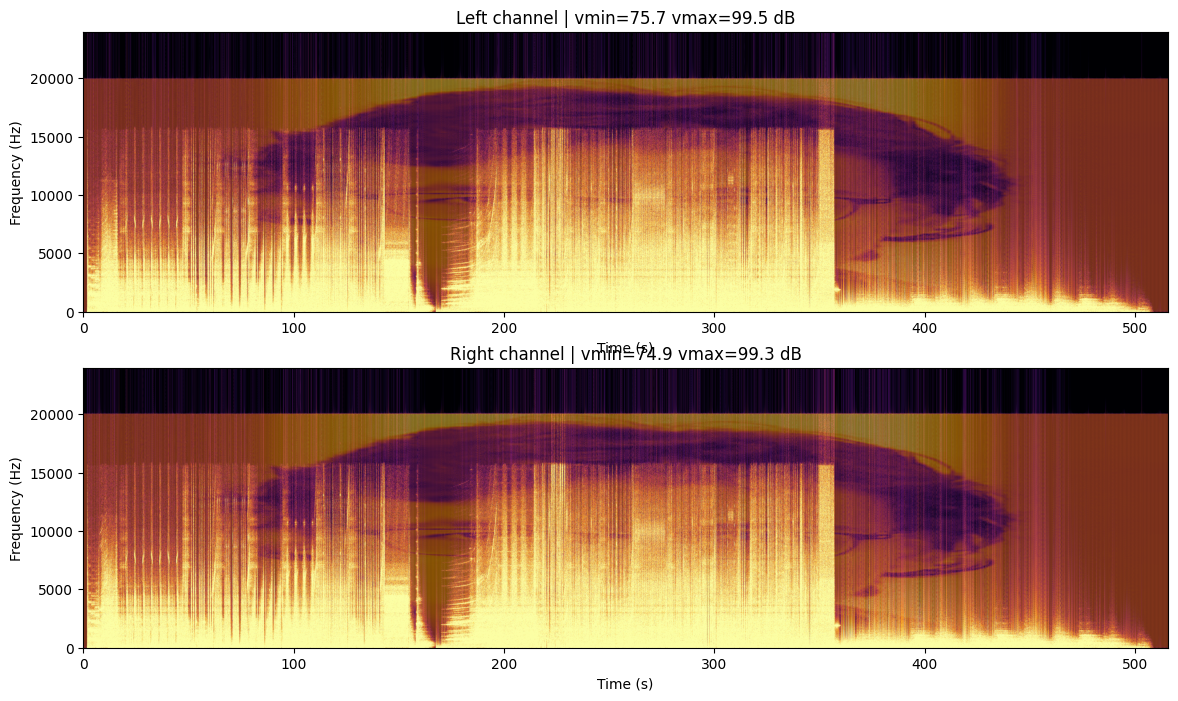

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, S, title in zip(axes, [S_left, S_right], ['Left channel', 'Right channel']):
    half = S.shape[1] // 2
    S_db = 10 * np.log10(np.maximum(np.abs(S[:, :half])**2, 1e-10))
    f_half = f[:half]

    # Crop to the EXACT time+frequency window being displayed
    duration = len(left) / sample_rate
    total_windows = S_db.shape[0]

    t_mask = np.linspace(0, duration, total_windows)
    time_mask = (t_mask >= 20) & (t_mask <= 24)
    freq_mask = (f_half >= 5000) & (f_half <= 16000)

    # Percentiles from only what's visible
    region = S_db[np.ix_(time_mask, freq_mask)]
    vmin = np.percentile(region, 10)
    vmax = np.percentile(region, 97)

    ax.imshow(
        S_db.T,
        aspect='auto',
        origin='lower',
        cmap='inferno',
        extent=[0, duration, 0, f_half[-1]],
        vmin=vmin, vmax=vmax,
    )
    ax.set_title(f'{title} | vmin={vmin:.1f} vmax={vmax:.1f} dB')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Frequency (Hz)')